# 03 - Compare Spatial vs Spatial + CV injected


In [1]:
# Requires: pip install -e .

from course_project.config import ExperimentConfig
from course_project.runner import run_graph_experiment


In [ ]:
import numpy as np
import torch
import pandas as pd
import json
from pathlib import Path
from course_project.data import load_dataset
from course_project.graph import build_graph
from course_project.metrics import evaluate_rollout_pratio_sides
from course_project.models import create_model, resolve_model_inputs
from course_project.utils import resolve_device

seed_base = 876541

full_dataset_path = '../data/2340_dePablo_networks_OOL_undirected.pt'
train_count = 3
val_count = 20

all_sims = load_dataset(full_dataset_path)
train_sims = all_sims[:train_count]
val_sims = all_sims[train_count:train_count + val_count]
test_sims = all_sims[train_count + val_count:]

print('Source dataset:', full_dataset_path)
print('Train sims:', len(train_sims), 'Val sims:', len(val_sims), 'Test sims:', len(test_sims))

time_lag_steps = 0
time_lag_weight = 0

common_cfg = dict(
    dataset_path=full_dataset_path,
    train_count=train_count,
    val_count=val_count,
    output_root='../results',
    pos_dim=2,
    history=1,
    limit=20,
    hidden_size=32,
    n_layers=2,
    learning_rate=1e-4,
    learning_rate_decay=1,
    weight_decay=0.0,
    epochs=200,
    val_every=10,
    rollout_every=10,
    cv_eval_every=10,
    rollout_steps=100,
    freeze_normalizers_after_epoch=10,
    device='cuda',
    seed=seed_base
)

best_cv_info = json.loads(Path('../results/cv_transformer_best_cv_selection.json').read_text())
best_cv_ckpt = Path(best_cv_info['saved_checkpoint_path'])
print('Using CV checkpoint:', best_cv_ckpt)
print('Best CV fit R2:', float(best_cv_info['best_cv_fit_r2']), 'epoch:', int(best_cv_info['best_cv_epoch']))

repeats = 10
rows = []

def evaluate_selected_checkpoint_on_test(cfg, run_metrics):
    run_dir = Path(cfg.output_root) / cfg.run_name
    final_ckpt = torch.load(run_dir / 'final_checkpoint.pt', map_location='cpu', weights_only=False)
    selected_checkpoint = Path(final_ckpt['selected_checkpoint']['path'])
    cfg_dict = json.loads((run_dir / 'config.json').read_text())
    device = resolve_device(cfg.device)
    init_frames = [test_sims[0][i].to(device) for i in range(cfg.history + 1)]
    init_graph = build_graph(init_frames).to(device)
    model = create_model(
        model_type=cfg.model_type,
        init_graph=init_graph,
        pos_dim=cfg.pos_dim,
        hidden_size=cfg.hidden_size,
        n_layers=cfg.n_layers,
        extras=cfg.model_extras,
    ).to(device)
    model.cfg = cfg_dict
    model.load_checkpoint(str(selected_checkpoint))
    model.eval()
    if hasattr(model, 'freeze_normalizers'):
        model.freeze_normalizers = True
    model_inputs_cls = resolve_model_inputs(cfg.model_type)
    with torch.no_grad():
        rollout_metrics = evaluate_rollout_pratio_sides(
            model=model,
            sims=test_sims,
            history=cfg.history,
            rollout_steps=cfg.rollout_steps,
            pos_dim=cfg.pos_dim,
            device=device,
            model_inputs_cls=model_inputs_cls,
        )
    out = dict(run_metrics)
    out['selected_checkpoint'] = str(selected_checkpoint)
    out['test_rollout_r2'] = float(rollout_metrics['rollout_r2'])
    out['test_rollout_pearson_r'] = float(rollout_metrics['rollout_pearson_r'])
    out['test_rollout_pos_mse'] = float(rollout_metrics['rollout_pos_mse'])
    return out

for i in range(repeats):
    seed = seed_base + i

    cfg_hybrid = ExperimentConfig(
        run_name=f'hybrid_r{i+1}',
        model_type='hybrid',
        model_extras={
            'num_mlp': 3,
            'cv_checkpoint_path': str(best_cv_ckpt),
            'cv_inject_scale_init': 0.25
            ,
            'time_lag_steps': time_lag_steps,
            'time_lag_weight': time_lag_weight,
        },
        **common_cfg,
    )

    cfg_spatial = ExperimentConfig(
        run_name=f'spatial_baseline_r{i+1}',
        model_type='spatial',
        model_extras={
            'num_mlp': 3,
        },
        **common_cfg,
    )

    m_hybrid_val = run_graph_experiment(cfg_hybrid)
    m_spatial_val = run_graph_experiment(cfg_spatial)
    m_hybrid = evaluate_selected_checkpoint_on_test(cfg_hybrid, m_hybrid_val)
    m_spatial = evaluate_selected_checkpoint_on_test(cfg_spatial, m_spatial_val)

    hybrid_ckpt = torch.load(Path(common_cfg['output_root']) / cfg_hybrid.run_name / 'final_checkpoint.pt', map_location='cpu', weights_only=False)
    hybrid_stats = torch.load(Path(common_cfg['output_root']) / cfg_hybrid.run_name / 'train_stats.pt', map_location='cpu', weights_only=False)

    m_hybrid['repeat'] = i + 1
    m_hybrid['cv_scale'] = float(hybrid_ckpt['model_state_dict']['cv_inject_scale'])
    m_hybrid['cv_film_mean'] = float(np.asarray(hybrid_stats['cv_film_mean'], dtype=float)[-1])

    m_spatial['repeat'] = i + 1
    m_spatial['cv_scale'] = np.nan
    m_spatial['cv_film_mean'] = np.nan

    rows.append(m_spatial)
    rows.append(m_hybrid)

runs = pd.DataFrame(rows)

runs_summary = runs[[
    'repeat',
    'run_name',
    'model_type',
    'best_epoch',
    'best_score',
    'rollout_r2',
    'rollout_pearson_r',
    'rollout_pos_mse',
    'test_rollout_r2',
    'test_rollout_pearson_r',
    'test_rollout_pos_mse',
    'cv_scale',
    'cv_film_mean',
]].sort_values(['model_type', 'repeat'])

compare = runs.groupby('model_type', as_index=False).agg(
    mean_val_selected_rollout_r2=('best_score', 'mean'),
    mean_test_rollout_r2=('test_rollout_r2', 'mean'),
    std_test_rollout_r2=('test_rollout_r2', 'std'),
    mean_test_rollout_pos_mse=('test_rollout_pos_mse', 'mean'),
)

print('Per-run results (checkpoint selected on val, final metrics on test):')
runs_summary



Source dataset: ../data/2340_dePablo_networks_OOL_undirected.pt
Train sims: 3 Val sims: 20 Test sims: 77
Using CV checkpoint: ../results/cv_transformer_best_cv_checkpoint.pt
Best CV fit R2: 0.9763090539339483 epoch: 100
[run] hybrid_r1 model=hybrid device=cuda output=../results/hybrid_r1
[run] training...
[train] time-lag loss tau=0 lambda=0
[ep  10/200] tr=0.947 va=0.853 lr=0.0001 cv_scale=0.248 film=0.209 roll=r2=0.417 p=0.928 mse=5.45e-05 (20/20) cv=|p|=nan r2=nan (n=0) t=32.4s
[ep  20/200] tr=0.957 va=0.854 lr=0.0001 cv_scale=0.247 film=0.209 roll=r2=0.536 p=0.953 mse=5.98e-05 (20/20) cv=|p|=nan r2=nan (n=0) t=33.7s
[ep  30/200] tr=0.95 va=0.853 lr=0.0001 cv_scale=0.247 film=0.209 roll=r2=0.462 p=0.934 mse=6.82e-05 (20/20) cv=|p|=nan r2=nan (n=0) t=35.7s
[ep  40/200] tr=0.94 va=0.857 lr=0.0001 cv_scale=0.248 film=0.208 roll=r2=0.431 p=0.93 mse=9.08e-05 (20/20) cv=|p|=nan r2=nan (n=0) t=34.2s
[ep  50/200] tr=0.932 va=0.86 lr=0.0001 cv_scale=0.248 film=0.208 roll=r2=0.532 p=0.933 mse

In [ ]:
print('Mean comparison (use this to compare models):')
compare

Mean comparison (use this to compare models):


,model_type,mean_val_selected_rollout_r2,mean_test_rollout_r2,std_test_rollout_r2,mean_test_rollout_pos_mse
0,hybrid,0.867177,0.880374,0.025747,0.000134
1,spatial,0.776709,0.823477,0.072438,0.000137


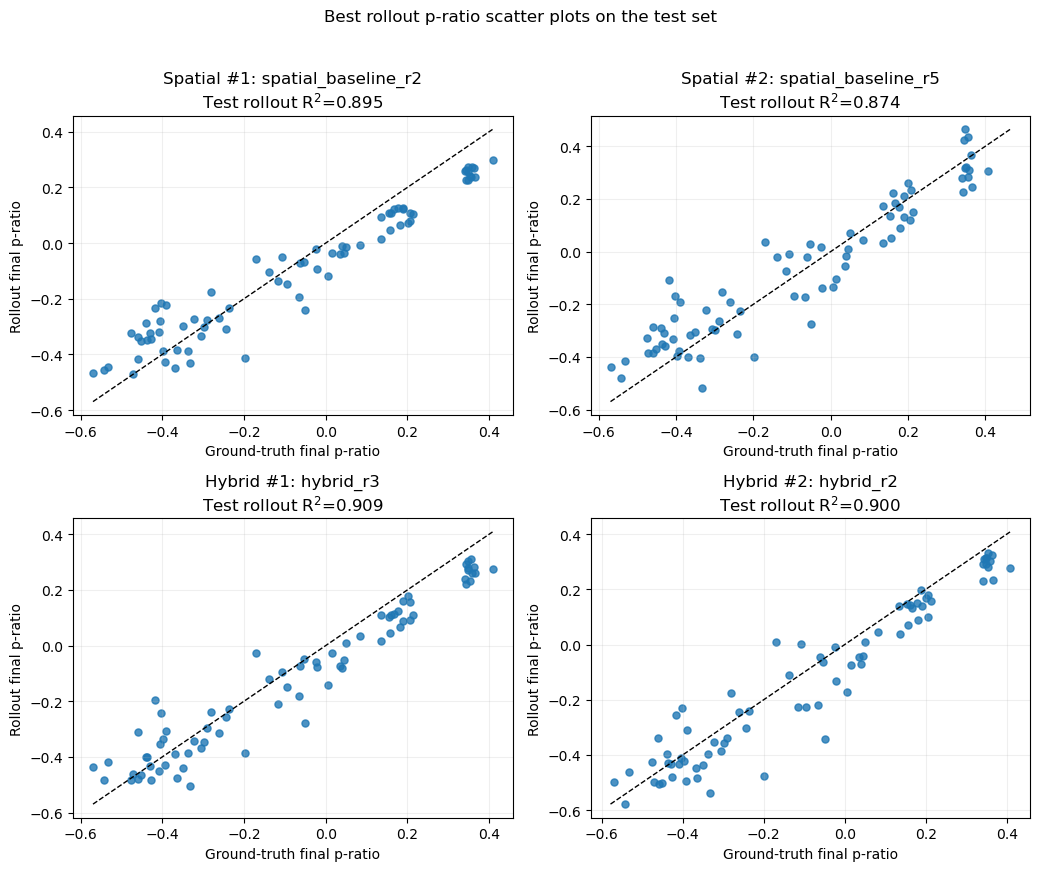

In [ ]:
# Scatter plots of ground-truth final p-ratio vs rollout final p-ratio for the top 2 runs of each model.
import matplotlib.pyplot as plt

def load_selected_model_for_test(row):
    run_dir = Path(common_cfg['output_root']) / row['run_name']
    cfg_dict = json.loads((run_dir / 'config.json').read_text())
    device = resolve_device(cfg_dict['device'])
    init_frames = [test_sims[0][i].to(device) for i in range(cfg_dict['history'] + 1)]
    init_graph = build_graph(init_frames).to(device)
    model = create_model(
        model_type=cfg_dict['model_type'],
        init_graph=init_graph,
        pos_dim=cfg_dict['pos_dim'],
        hidden_size=cfg_dict['hidden_size'],
        n_layers=cfg_dict['n_layers'],
        extras=cfg_dict['model_extras'],
    ).to(device)
    model.cfg = cfg_dict
    model.load_checkpoint(str(row['selected_checkpoint']))
    model.eval()
    if hasattr(model, 'freeze_normalizers'):
        model.freeze_normalizers = True
    return model, cfg_dict, device

def collect_rollout_scatter_rows(row):
    model, cfg_dict, device = load_selected_model_for_test(row)
    model_inputs_cls = resolve_model_inputs(cfg_dict['model_type'])
    with torch.no_grad():
        metrics = evaluate_rollout_pratio_sides(
            model=model,
            sims=test_sims,
            history=cfg_dict['history'],
            rollout_steps=cfg_dict['rollout_steps'],
            pos_dim=cfg_dict['pos_dim'],
            device=device,
            model_inputs_cls=model_inputs_cls,
        )
    return pd.DataFrame(metrics['rows'])

top_spatial = runs[runs['model_type'] == 'spatial'].sort_values('test_rollout_r2', ascending=False).head(2)
top_hybrid = runs[runs['model_type'] == 'hybrid'].sort_values('test_rollout_r2', ascending=False).head(2)
panel_rows = [top_spatial.iloc[i] for i in range(len(top_spatial))] + [top_hybrid.iloc[i] for i in range(len(top_hybrid))]
panel_titles = ['Spatial #1', 'Spatial #2', 'Hybrid #1', 'Hybrid #2']

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5))
axes = axes.flatten()

for ax, row, panel_title in zip(axes, panel_rows, panel_titles):
    scatter_df = collect_rollout_scatter_rows(row)
    x = scatter_df['target_rollout_sides_p_ratio'].to_numpy(dtype=float)
    y = scatter_df['pred_rollout_p_ratio'].to_numpy(dtype=float)
    ax.scatter(x, y, s=26, alpha=0.8)
    lo = float(min(x.min(), y.min()))
    hi = float(max(x.max(), y.max()))
    ax.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1)
    ax.set_title(f"{panel_title}: {row['run_name']}\nTest rollout R$^2$={row['test_rollout_r2']:.3f}")
    ax.set_xlabel('Ground-truth final p-ratio')
    ax.set_ylabel('Rollout final p-ratio')
    ax.grid(alpha=0.2)

for ax in axes[len(panel_rows):]:
    ax.axis('off')

fig.suptitle('Best rollout p-ratio scatter plots on the test set', y=1.02)
plt.tight_layout()
plt.show()
